In [1]:
>>> import vectorbt as vbt

>>> data = vbt.YFData.download("BTC-USD")
>>> price = data.get("Close")

>>> pf = vbt.Portfolio.from_holding(price, init_cash=100)
>>> print(pf.total_profit())


15496.449173861252


In [2]:
>>> fast_ma = vbt.MA.run(price, 10)
>>> slow_ma = vbt.MA.run(price, 50)
>>> entries = fast_ma.ma_crossed_above(slow_ma)
>>> exits = fast_ma.ma_crossed_below(slow_ma)

>>> pf = vbt.Portfolio.from_signals(price, entries, exits, init_cash=100)
>>> print(pf.total_profit())


30782.047433056716


C:\Users\yellow\.conda\envs\venv\Lib\site-packages\vectorbt\data\base.py:535: UserWarning: Symbols have mismatching index. Dropping missing data points.
  data = cls.align_index(data, missing=missing_index)


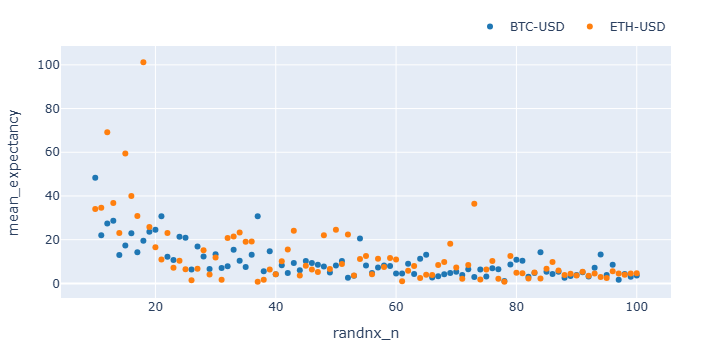

In [3]:
>>> import numpy as np

>>> symbols = ["BTC-USD", "ETH-USD"]
>>> data = vbt.YFData.download(symbols, missing_index="drop")
>>> price = data.get("Close")

>>> n = np.random.randint(10, 101, size=1000).tolist()
>>> pf = vbt.Portfolio.from_random_signals(price, n=n, init_cash=100, seed=42)

>>> mean_expectancy = pf.trades.expectancy().groupby(["randnx_n", "symbol"]).mean()
>>> fig = mean_expectancy.unstack().vbt.scatterplot(xaxis_title="randnx_n", yaxis_title="mean_expectancy")
>>> fig.show()

C:\Users\yellow\.conda\envs\venv\Lib\site-packages\vectorbt\data\base.py:535: UserWarning: Symbols have mismatching index. Dropping missing data points.
  data = cls.align_index(data, missing=missing_index)


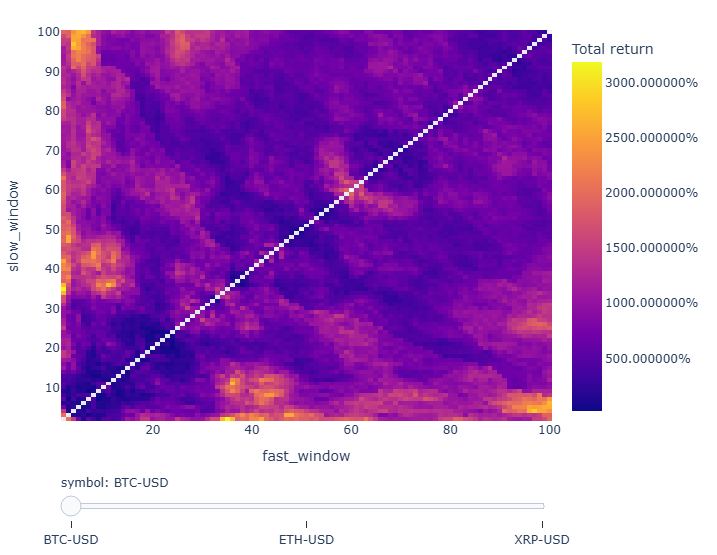

In [4]:
>>> symbols = ["BTC-USD", "ETH-USD", "XRP-USD"]
>>> data = vbt.YFData.download(symbols, missing_index="drop")
>>> price = data.get("Close")

>>> windows = np.arange(2, 101)
>>> fast_ma, slow_ma = vbt.MA.run_combs(price, window=windows, r=2, short_names=["fast", "slow"])
>>> entries = fast_ma.ma_crossed_above(slow_ma)
>>> exits = fast_ma.ma_crossed_below(slow_ma)

>>> pf = vbt.Portfolio.from_signals(price, entries, exits, size=np.inf, fees=0.001, freq="1D")

>>> fig = pf.total_return().vbt.heatmap(
...     x_level="fast_window", y_level="slow_window", slider_level="symbol", symmetric=True,
...     trace_kwargs=dict(colorbar=dict(title="Total return", tickformat="%")))
>>> fig.show()

In [5]:
print(pf[(10, 20, "ETH-USD")].stats())

Start                          2017-11-09 00:00:00+00:00
End                            2026-06-01 00:00:00+00:00
Period                                3127 days 00:00:00
Start Value                                        100.0
End Value                                    1411.120875
Total Return [%]                             1311.120875
Benchmark Return [%]                          510.351405
Max Gross Exposure [%]                             100.0
Total Fees Paid                               214.636341
Max Drawdown [%]                               70.734951
Max Drawdown Duration                 1095 days 00:00:00
Total Trades                                          84
Total Closed Trades                                   84
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                    40.47619
Best Trade [%]                                120.511071
Worst Trade [%]                

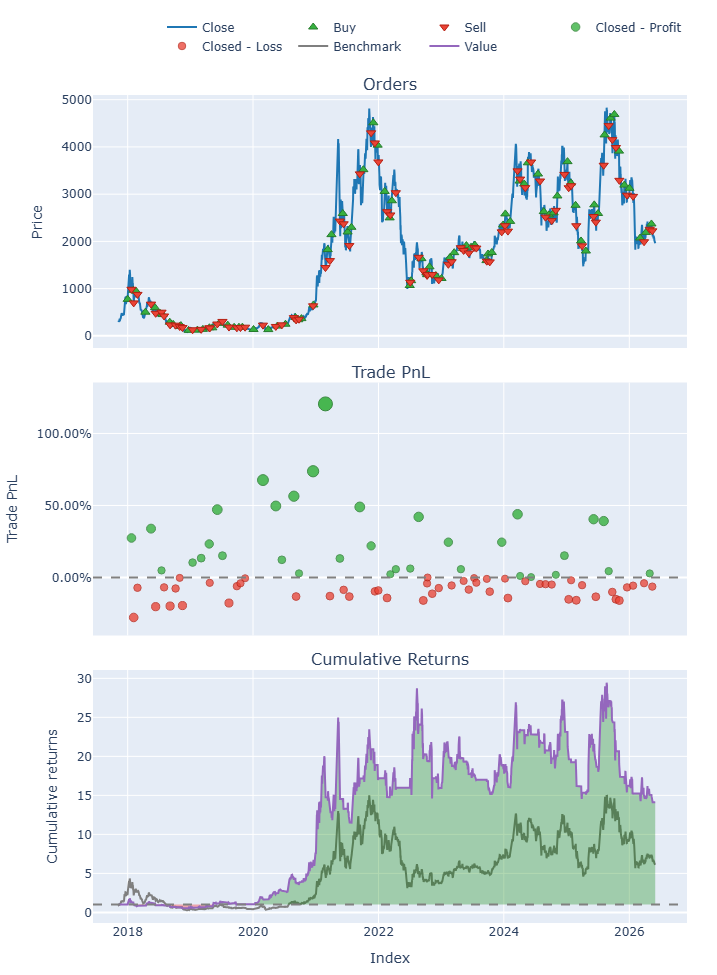

In [6]:
pf[(10, 20, "ETH-USD")].plot().show()

In [ ]:
>>> symbols = ["BTC-USD", "ETH-USD", "XRP-USD"]
>>> data = vbt.YFData.download(symbols, period="6mo", missing_index="drop")
>>> price = data.get("Close")
>>> bbands = vbt.BBANDS.run(price)

>>> def plot(index, bbands):
...     bbands = bbands.loc[index]

...     fig = vbt.make_subplots(
...         rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.15,
...         subplot_titles=("%B", "Bandwidth"))
...     fig.update_layout(showlegend=False, width=750, height=400)
...     bbands.percent_b.vbt.ts_heatmap(
...         trace_kwargs=dict(zmin=0, zmid=0.5, zmax=1, colorscale="Spectral", colorbar=dict(
...             y=(fig.layout.yaxis.domain[0] + fig.layout.yaxis.domain[1]) / 2, len=0.5
...         )), add_trace_kwargs=dict(row=1, col=1), fig=fig)
...     bbands.bandwidth.vbt.ts_heatmap(
...         trace_kwargs=dict(colorbar=dict(
...             y=(fig.layout.yaxis2.domain[0] + fig.layout.yaxis2.domain[1]) / 2, len=0.5
...         )), add_trace_kwargs=dict(row=2, col=1), fig=fig)
...     return fig

>>> vbt.save_animation("bbands.gif", bbands.wrapper.index, plot, bbands, delta=90, step=3, fps=3)
